# Getting Started with PySUS

*Your complete guide to accessing Brazilian public health data*

**PySUS v3.0.0+ · Python 3.10-3.13**

Notebook contribution — [AlertaDengue/PySUS](https://github.com/AlertaDengue/PySUS)

---

## Introduction

PySUS is a Python library that provides easy access to publicly available datasets
from Brazil's Unified Health System (SUS), published by DATASUS.
It handles background cloud orchestrations, downloading, and local schema management — so you can focus on data analysis
rather than dealing with legacy download workflows.

This notebook presents a complete beginner-friendly workflow,
from installation to the first data exploration using real SUS data.

> **No prior knowledge of DATASUS is required.**
> All datasets are optimized as parquet records and fetched securely via our high-performance backend pipelines.

---
## 1. Installation

Install PySUS using `pip`.
If you are working inside a virtual environment (recommended), activate it first.

```
pip install pysus
```

> **Tip:** Using a virtual environment keeps your project dependencies isolated.
> ```
> python -m venv venv
> source venv/bin/activate      # Linux / macOS
> venv\Scripts\activate         # Windows
> ```

In [1]:
# Run this cell if PySUS is not yet installed
%pip install pysus

Note: you may need to restart the kernel to use updated packages.


---
## 2. Checking Your Installation

After installing PySUS, verify that the package is available and check the installed version.

In [2]:
import pysus

print(pysus.get_version())

2.1.0


---
## 3. Exploring the Package

PySUS exposes each health dataset as a simple callable function.
Use `dir(pysus)` to see the API entry points available:

In [3]:
import pysus

print([item for item in dir(pysus) if not item.startswith('_')])

['CACHEPATH', 'Final', 'api', 'ciha', 'cnes', 'get_version', 'ibge', 'importlib_metadata', 'list_files', 'os', 'pathlib', 'pni', 'sia', 'sih', 'sim', 'sinan', 'sinasc', 'version']


The main dataset functions are:

| Function | Dataset | Description |
|----------|---------|-------------|
| `sinasc()` | SINASC | Live birth records |
| `sim()` | SIM | Mortality records |
| `sinan()` | SINAN | Notifiable diseases |
| `sih()` | SIH | Hospital admissions |
| `sia()` | SIA | Outpatient procedures |
| `cnes()` | CNES | Health facilities |
| `pni()` | PNI | Immunisation programme |
| `ibge()` | IBGE | Demographic data |

---
## 4. Understanding the Parameters

All dataset functions share the same unified parameter pattern. For instance, querying `sinasc()` can be targeted like this:

```python
sinasc(
    state = "SP",   # two-letter Brazilian state code
    year  = 2022,   # integer, list, or range of integers
)
```

| Parameter | Type | Description | Example |
|-----------|------|-------------|---------|
| `state` | `str` | Two-letter state abbreviation | `"SP"`, `"RJ"`, `"MG"` |
| `year` | `int`, `list` or `range` | Targets execution span | `2022` or `range(2020, 2026)` |
| `group` | `str` or `None` | Sub-group code (SINAN only) | `"DENG"` (dengue) |
| `as_dataframe` | `bool` | Instantly return a Pandas Dataframe | `True` or `False` |

---
## 5. Downloading Your First Dataset

Let's download SINASC birth records for Rio de Janeiro, 2022.
By default, the function handles throttled parallel downloads and returns a list of local file paths tracking your parquet targets.

In [4]:
from pysus import sinasc
import pandas as pd

# Fetch local storage paths for the dataset
files = sinasc(state="RJ", year=2022)
print(f"Parquet file targets saved locally: {files}")

# Open records with pandas
df = pd.read_parquet(files)

Parquet file targets saved locally: ['/home/bida/pysus/downloads/ducklake/sinasc/DNRJ2022.parquet']


> **Tip:** To download an entire multi-year range automatically into a unified dataframe framework, pass `as_dataframe=True`:
> ```python
> df = sinasc(state="SP", year=range(2020, 2025), as_dataframe=True)
> ```

---
## 6. Inspecting the Data

Three essential commands for exploring your newly loaded DataFrame:

In [5]:
# Shape: number of rows and columns
print(df.shape)

(180369, 61)


In [6]:
# Column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180369 entries, 0 to 180368
Data columns (total 61 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   ORIGEM      180369 non-null  object
 1   CODESTAB    180369 non-null  object
 2   CODMUNNASC  180369 non-null  object
 3   LOCNASC     180369 non-null  object
 4   IDADEMAE    180369 non-null  object
 5   ESTCIVMAE   180369 non-null  object
 6   ESCMAE      180369 non-null  object
 7   CODOCUPMAE  180369 non-null  object
 8   QTDFILVIVO  180369 non-null  object
 9   QTDFILMORT  180369 non-null  object
 10  CODMUNRES   180369 non-null  object
 11  GESTACAO    180369 non-null  object
 12  GRAVIDEZ    180369 non-null  object
 13  PARTO       180369 non-null  object
 14  CONSULTAS   180369 non-null  object
 15  DTNASC      180369 non-null  object
 16  HORANASC    180369 non-null  object
 17  SEXO        180369 non-null  object
 18  APGAR1      180369 non-null  object
 19  APGAR5      180369 non-

In [7]:
# Statistical baseline summaries
df.describe()

,ORIGEM,CODESTAB,CODMUNNASC,LOCNASC,IDADEMAE,ESTCIVMAE,ESCMAE,CODOCUPMAE,QTDFILVIVO,QTDFILMORT,...,TPDOCRESP,DTDECLARAC,ESCMAEAGR1,STDNEPIDEM,STDNNOVA,CODPAISRES,TPROBSON,PARIDADE,KOTELCHUCK,CONTADOR
count,180369,180369,180369,180369,180369,180369,180369,180369,180369,180369,...,180369,180369,180369,180369,180369,180369,180369,180369,180369,180369
unique,1,323,150,5,51,7,7,876,20,17,...,6,380,14,2,1,1,11,2,6,180369
top,1,7011857,330455,1,25,1,4,999992,00,00,...,3,,06,0,1,1,05,1,5,14077
freq,180369,6041,69427,178781,9583,112610,111474,77806,76238,136704,...,75107,2157,42874,180352,180369,180369,43545,111897,117184,1


Key SINASC columns you will encounter:

| Column | Description |
|--------|-------------|
| `DTNASC` | Birth date (format: DDMMYYYY) |
| `IDADEMAE` | Mother's age in years |
| `ESCMAE` | Mother's years of schooling |
| `PARTO` | Type of delivery (1 = vaginal, 2 = caesarean) |
| `CONSULTAS` | Number of prenatal visits |
| `SEXO` | Sex of the newborn |
| `PESO` | Birth weight in grams |

---
## 7. Data Visualisation

Let's plot the **monthly distribution of births** in Rio de Janeiro for 2022.

The column `DTNASC` stores the birth date in the format `DDMMYYYY`.
We extract the month from it and create a simple bar chart.

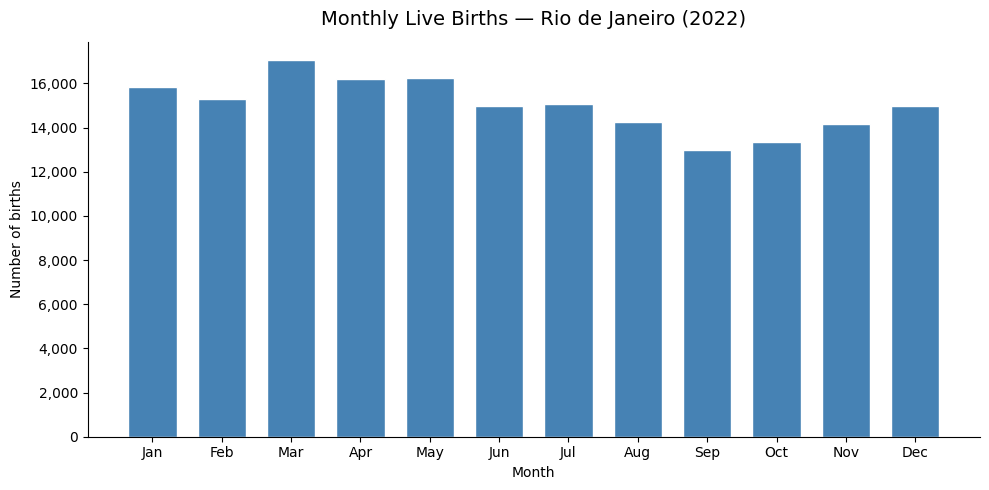


Total births plotted: 180,369


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Parse birth month from DTNASC (format: DDMMYYYY)
df["birth_month"] = pd.to_datetime(
    df["DTNASC"], format="%d%m%Y", errors="coerce"
).dt.month

# Count births per month
monthly = df["birth_month"].value_counts().sort_index()

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    range(1, len(monthly) + 1),
    monthly.values,
    color="steelblue",
    edgecolor="white",
    width=0.7,
)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"{int(x):,}")
)
ax.set_title("Monthly Live Births — Rio de Janeiro (2022)", fontsize=14, pad=12)
ax.set_xlabel("Month")
ax.set_ylabel("Number of births")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\nTotal births plotted: {monthly.sum():,}")

---
## 8. Available Data Sources

PySUS provides accelerated access to the following official DATASUS structures:

| Dataset | Full name | Coverage |
|---------|-----------|----------|
| SINASC | Sistema de Informação sobre Nascidos Vivos | Live births, all states, 1994–present |
| SIM | Sistema de Informação sobre Mortalidade | Deaths, all states, 1979–present |
| SINAN | Sistema de Informação de Agravos de Notificação | Notifiable diseases (dengue, TB, etc.) |
| SIH | Sistema de Informações Hospitalares | Hospital admissions, 1992–present |
| SIA | Sistema de Informações Ambulatoriais | Outpatient procedures |
| CNES | Cadastro Nacional de Estabelecimentos de Saúde | Health facilities registry |
| PNI | Programa Nacional de Imunizações | Vaccination data |
| IBGE | Instituto Brasileiro de Geografia e Estatística | Population and demographic data |